# Keyword trend modeling

Predicts next-year change in a word's share of thesis titles within a subject,
for words already flagged as rising by the EDA notebook's method.

**Design choices:**
- Rising-word candidates are selected using only data up to a cutoff year
  (`SELECT_END`), never data from the test window, so the model can't benefit
  from knowing which words turned out to matter.
- Specificity and other features are computed cumulatively (using only years
  up to and including the current one), not from all-years totals.
- The panel is zero-filled: a year where a word doesn't appear counts as
  share = 0, not a skipped row.
- Target is **change in share** (`dshare = share(t+1) - share(t)`), not the
  raw share, so metrics measure real predictive skill instead of rewarding
  the model for just copying last year's number.
- Sample weights are next-year title-word volume, so noisy small-subject-years
  count less.
- Baselines: zero-change (persistence) and momentum (`pred = slope_3yr`),
  both need to be beaten for the model to be worth anything.

**Inputs:** `data/word_year_subject_v5_final.parquet`,
`data/subject_meta_v5_final.parquet` (from `01_build_parquets.ipynb`).


In [31]:
# %% [imports]
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import Ridge
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, ndcg_score
from sklearn.utils import shuffle

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120


In [32]:
try:
    from nltk.stem import PorterStemmer
    _ps = PorterStemmer()
    def _stem_parts(w):
        return tuple(_ps.stem(p) for p in w.split("_"))
except ImportError:
    # fallback: crude suffix strip if nltk isn't available
    def _stem_parts(w):
        out = []
        for p in w.split("_"):
            for suf in ("ing", "tion", "ed", "s"):
                if p.endswith(suf) and len(p) - len(suf) >= 3:
                    p = p[:-len(suf)]; break
            out.append(p)
        return tuple(out)

In [33]:
# %% [load]
PIPELINE_VERSION = "v5_final"   # must match the build_parquets run this reads from
raw  = pd.read_parquet(f"data/word_year_subject_{PIPELINE_VERSION}.parquet")
meta = pd.read_parquet(f"data/subject_meta_{PIPELINE_VERSION}.parquet")


In [34]:
# %% [2-year binning: rebuild the year axis into consecutive 2-year periods]
BIN_WIDTH = 2

r = raw.copy()
last_year = int(r["year"].max())
r["period"] = (last_year - r["year"]) // BIN_WIDTH          # 0 = newest bin

# calendar-year label per bin, and a time-increasing integer axis (newest = highest)
edges = r.groupby("period")["year"].agg(["min", "max"])
pmax  = int(edges.index.max())
r["yidx"] = pmax - r["period"]
period_labels = {pmax - p: f"{row['min']}-{row['max']}" for p, row in edges.iterrows()}

# one total per (subject, original year) so totals are not multiplied across words
syt_year = raw.groupby(["subject", "year"])["total_title_words"].first().reset_index()
syt_year["yidx"] = pmax - ((last_year - syt_year["year"]) // BIN_WIDTH)
tot_bin = syt_year.groupby(["subject", "yidx"])["total_title_words"].sum().reset_index()

# counts summed within each bin
cnt_bin = r.groupby(["subject", "word", "yidx"])["count"].sum().reset_index()

# 'year' now holds the bin index -> downstream code is unchanged
raw = (cnt_bin.merge(tot_bin, on=["subject", "yidx"])
       .rename(columns={"yidx": "year"}))

print("Bins (index -> calendar years):")
for k in sorted(period_labels):
    print(f"  {k}: {period_labels[k]}")


Bins (index -> calendar years):
  0: 1747-1747
  10: 1768-1768
  22: 1792-1792
  37: 1822-1822
  40: 1828-1828
  52: 1852-1852
  53: 1853-1853
  56: 1860-1860
  57: 1861-1862
  58: 1863-1863
  59: 1865-1865
  60: 1867-1867
  62: 1872-1872
  63: 1873-1874
  64: 1875-1876
  65: 1878-1878
  66: 1880-1880
  68: 1883-1884
  69: 1885-1886
  70: 1887-1888
  71: 1889-1890
  72: 1891-1892
  73: 1893-1894
  74: 1895-1896
  75: 1897-1898
  76: 1899-1900
  77: 1901-1902
  78: 1903-1904
  79: 1905-1906
  80: 1907-1908
  81: 1909-1910
  82: 1911-1912
  83: 1913-1914
  84: 1915-1916
  85: 1917-1918
  86: 1919-1920
  87: 1921-1922
  88: 1923-1924
  89: 1925-1926
  90: 1927-1928
  91: 1929-1930
  92: 1931-1932
  93: 1933-1934
  94: 1935-1936
  95: 1937-1938
  96: 1939-1940
  97: 1941-1942
  98: 1943-1944
  99: 1945-1946
  100: 1947-1948
  101: 1949-1950
  102: 1951-1952
  103: 1953-1954
  104: 1955-1956
  105: 1957-1958
  106: 1959-1960
  107: 1961-1962
  108: 1963-1964
  109: 1965-1966
  110: 1967-196

In [35]:
import pandas as pd
pd.set_option("display.max_rows", None)   # print every bin

bin_vol = (raw.groupby(["subject", "year"])["total_title_words"].first()
           .groupby("year").sum()
           .rename("title_words"))

lbl = bin_vol.index.map(period_labels)     # attach 2021-2022 style labels
out = pd.DataFrame({"bin": bin_vol.index, "years": lbl, "title_words": bin_vol.values})
print(out.to_string(index=False))

pd.reset_option("display.max_rows")

 bin     years  title_words
   0 1747-1747            2
  10 1768-1768            2
  22 1792-1792            8
  37 1822-1822            3
  40 1828-1828            1
  52 1852-1852            5
  53 1853-1853            9
  56 1860-1860            7
  57 1861-1862           26
  58 1863-1863            9
  59 1865-1865            5
  60 1867-1867            4
  62 1872-1872            4
  63 1873-1874           13
  64 1875-1876           17
  65 1878-1878            3
  66 1880-1880           18
  68 1883-1884           12
  69 1885-1886           21
  70 1887-1888           19
  71 1889-1890           21
  72 1891-1892           41
  73 1893-1894           30
  74 1895-1896           42
  75 1897-1898           54
  76 1899-1900           41
  77 1901-1902           49
  78 1903-1904           28
  79 1905-1906           78
  80 1907-1908           78
  81 1909-1910           81
  82 1911-1912           55
  83 1913-1914           94
  84 1915-1916          109
  85 1917-1918      

In [36]:
MIN_VOLUME_PER_BIN = 1000

_syt_all   = raw.groupby(["subject", "year"])["total_title_words"].first().reset_index()
bin_volume = _syt_all.groupby("year")["total_title_words"].sum().sort_index()
START_YEAR = int(bin_volume[bin_volume >= MIN_VOLUME_PER_BIN].index.min())

TREND_END  = int(raw["year"].max()) - 1   # 138 = 2023-2024, last complete bin
TEST_YEARS = 5
SELECT_END = TREND_END - TEST_YEARS       # 133 = 2013-2014
SPLIT_YEAR = SELECT_END + 1               # 134

RECENT     = 5    # selection slope over 5 bins
# MIN_YEAR_WORDS, MIN_TOTAL, SPEC_MIN, TOP_K unchanged

print(f"START_YEAR: {START_YEAR} ({period_labels[START_YEAR]})")
print(f"SELECT_END: {SELECT_END} ({period_labels[SELECT_END]})")
print(f"SPLIT_YEAR: {SPLIT_YEAR} ({period_labels[SPLIT_YEAR]})")
print(f"TREND_END:  {TREND_END} ({period_labels[TREND_END]})")

START_YEAR: 101 (1949-1950)
SELECT_END: 133 (2013-2014)
SPLIT_YEAR: 134 (2015-2016)
TREND_END:  138 (2023-2024)


In [37]:
# %% [parameters -- derived from the binned window above, rest are fixed choices]

TEST_YEARS  = 5    # bins held out for testing (5 bins = 10 years)
SELECT_END  = TREND_END - TEST_YEARS      # rising words chosen using data <= this bin
SPLIT_YEAR  = SELECT_END + 1              # train < SPLIT_YEAR, test >= SPLIT_YEAR

MIN_YEAR_WORDS = 50     # min title-words in a subject-bin
MIN_TOTAL      = 10     # min cumulative count for a candidate word
SPEC_MIN       = 1.5    # subject share / global share floor
RECENT         = 5      # bins for the selection slope (5 bins = 10 years)
TOP_K          = 10     # rising words kept per subject

assert SELECT_END < SPLIT_YEAR, "selection must not see the test window"

FEATURES = ["share_lag1", "share_lag2", "share_lag3",
            "slope_3yr", "slope_5yr", "accel", "vol_5yr",
            "spec_cum", "word_age", "log_volume"]

print(f"SELECT_END: {SELECT_END} ({period_labels[SELECT_END]}) | "
      f"SPLIT_YEAR: {SPLIT_YEAR} ({period_labels[SPLIT_YEAR]}) | "
      f"TREND_END: {TREND_END} ({period_labels[TREND_END]})")

SELECT_END: 133 (2013-2014) | SPLIT_YEAR: 134 (2015-2016) | TREND_END: 138 (2023-2024)


In [38]:
df = raw[
    (raw["year"] >= START_YEAR) &
    (raw["year"] <= TREND_END) &
    (raw["total_title_words"] >= MIN_YEAR_WORDS)
].copy()

# one row per (subject, bin): token totals (constant across words within a subject-bin)
subj_year_tot = (
    df.groupby(["subject", "year"])["total_title_words"]
    .first().rename("total").reset_index()
)
print(f"Rows: {len(df):,} | subjects: {df['subject'].nunique()} | "
      f"bins {df['year'].min()}-{df['year'].max()} "
      f"({period_labels[df['year'].min()]} to {period_labels[df['year'].max()]})")

Rows: 344,606 | subjects: 61 | bins 101-138 (1949-1950 to 2023-2024)


In [39]:
# %% [leak-free rising-word selection]
# Same idea as the EDA notebook's rising-word detection, but everything here
# is computed strictly from data <= end_year, so selecting candidates never
# uses information the test window wouldn't have had yet.

def select_rising_pairs(d, syt, end_year,
                        recent=RECENT, min_total=MIN_TOTAL,
                        spec_min=SPEC_MIN, top_k=TOP_K):
    d = d[d["year"] <= end_year]

    # cumulative counts up to end_year
    pair_tot  = d.groupby(["subject", "word"])["count"].sum()
    subj_tot  = d.groupby("subject")["count"].sum()
    glob_word = d.groupby("word")["count"].sum()
    glob_tot  = glob_word.sum()

    cand = pair_tot[pair_tot >= min_total].reset_index()
    subj_share = cand["count"] / cand["subject"].map(subj_tot)
    glob_share = cand["word"].map(glob_word) / glob_tot
    cand["spec"] = subj_share / np.maximum(glob_share, 1e-9)
    cand = cand[cand["spec"] >= spec_min]

    # recent slope on zero-filled shares (vectorized least squares)
    years = np.arange(end_year - recent + 1, end_year + 1)
    dr = d[d["year"].isin(years)]
    counts = (
        dr.pivot_table(index=["subject", "word"], columns="year",
                       values="count", aggfunc="sum")
        .reindex(columns=years).fillna(0.0)
    )
    counts = counts.join(
        pd.DataFrame(index=cand.set_index(["subject", "word"]).index),
        how="inner")
    totals = (
        syt[syt["year"].isin(years)]
        .pivot(index="subject", columns="year", values="total")
        .reindex(columns=years)
    )
    tot_aligned = totals.reindex(counts.index.get_level_values("subject")).values
    shares = counts.values / np.where(np.isnan(tot_aligned) | (tot_aligned == 0),
                                      np.nan, tot_aligned)
    valid = (~np.isnan(shares)).sum(axis=1) >= 5

    x  = np.arange(recent, dtype=float)
    xc = x - x.mean()
    sh = np.nan_to_num(shares, nan=0.0)          # missing subject-years -> 0 share
    slope = (sh @ xc) / (xc @ xc) * 10 * 100     # %-points per decade

    out = counts.index.to_frame(index=False)
    out["recent_slope"] = slope
    out = out[valid]
    out = out.merge(cand[["subject", "word", "spec", "count"]]
                    .rename(columns={"count": "total"}),
                    on=["subject", "word"])
    out["enriched"] = (out["recent_slope"] * out["spec"]
                       / np.log1p(glob_word[out["word"]].values))

    # underscore-aware prefix dedup within subject (keep higher total).
    # only merges words that share the same underscore-delimited token
    # prefix (e.g. learn/learning), so a unigram like "machine" can't
    # swallow an unrelated bigram like "machine_learning".
    def dedup(g):
        keep = []          # list of stemmed-part tuples already kept
        keep_words = []
        for w in g.sort_values("total", ascending=False)["word"]:
            wp = _stem_parts(w)
            dominated = any(
                kp == wp[:len(kp)] or wp == kp[:len(wp)]
                for kp in keep
            )
            if not dominated:
                keep.append(wp)
                keep_words.append(w)
        return g[g["word"].isin(keep_words)]

    out = out.query("recent_slope > 0")
    out = pd.concat([dedup(g) for _, g in out.groupby("subject")],
                    ignore_index=True)
    return (out.sort_values("enriched", ascending=False)
            .groupby("subject").head(top_k)
            .reset_index(drop=True))

rising = select_rising_pairs(df, subj_year_tot, end_year=SELECT_END)
pairs  = rising[["subject", "word"]].drop_duplicates()
print(f"Rising pairs (selected as of {SELECT_END}): {len(pairs)} "
      f"across {pairs['subject'].nunique()} subjects")


Rising pairs (selected as of 133): 460 across 50 subjects


In [40]:
# %% [feature panel builder -- shared by training and the watchlist]
# Axis is now 2-year BINS. Lags/rolling windows count bins, not calendar years
# (e.g. share_lag1 = previous bin = 2 years back; slope_5yr = 5-bin slope).

def rolling_slope(s, window):
    def _s(x):
        if np.any(np.isnan(x)):
            return np.nan
        return np.polyfit(range(len(x)), x, 1)[0]
    return s.rolling(window).apply(_s, raw=True)

def build_feature_panel(d, syt, pair_df):
    """Zero-filled (subject, word, bin) panel with leak-free features.
    All features at bin t use information from bins <= t only."""
    grid = pair_df.merge(syt, on="subject")
    pn = (grid.merge(d[["subject", "word", "year", "count"]],
                     on=["subject", "word", "year"], how="left")
          .fillna({"count": 0}))
    pn["share"] = pn["count"] / pn["total"]
    pn = pn.sort_values(["subject", "word", "year"]).reset_index(drop=True)

    g = pn.groupby(["subject", "word"], sort=False)
    pn["share_lag1"] = g["share"].shift(1)
    pn["share_lag2"] = g["share"].shift(2)
    pn["share_lag3"] = g["share"].shift(3)
    pn["slope_3yr"]  = g["share"].transform(lambda s: rolling_slope(s, 3))  # 3 bins
    pn["slope_5yr"]  = g["share"].transform(lambda s: rolling_slope(s, 5))  # 5 bins
    pn["accel"]      = pn["slope_3yr"] - pn["slope_5yr"]
    pn["vol_5yr"]    = g["share"].transform(lambda s: s.rolling(5).std())   # 5 bins

    first_seen = (pn[pn["count"] > 0].groupby(["subject", "word"])["year"]
                  .min().rename("first_year"))
    pn = pn.merge(first_seen, on=["subject", "word"], how="left")
    pn["word_age"]   = (pn["year"] - pn["first_year"]).clip(lower=0)   # age in bins
    pn["log_volume"] = np.log1p(pn["total"])

    # cumulative (leak-free) specificity
    g = pn.groupby(["subject", "word"], sort=False)
    pn["cum_count"] = g["count"].cumsum()
    sc = syt.sort_values(["subject", "year"]).copy()
    sc["subj_cum_tot"] = sc.groupby("subject")["total"].cumsum()
    pn = pn.merge(sc[["subject", "year", "subj_cum_tot"]], on=["subject", "year"])

    words = pair_df["word"].unique()
    gw = (d[d["word"].isin(words)]
          .groupby(["word", "year"])["count"].sum().rename("gcount").reset_index())
    yg = (pn[["word", "year"]].drop_duplicates()
          .merge(gw, on=["word", "year"], how="left").fillna({"gcount": 0})
          .sort_values(["word", "year"]))
    yg["g_cum"] = yg.groupby("word")["gcount"].cumsum()
    gt = d.groupby("year")["count"].sum().rename("gtot").reset_index().sort_values("year")
    gt["gtot_cum"] = gt["gtot"].cumsum()
    yg = yg.merge(gt[["year", "gtot_cum"]], on="year")
    pn = pn.merge(yg[["word", "year", "g_cum", "gtot_cum"]], on=["word", "year"])
    pn["spec_cum"] = (
        (pn["cum_count"] / pn["subj_cum_tot"].clip(lower=1))
        / np.maximum(pn["g_cum"] / pn["gtot_cum"].clip(lower=1), 1e-9)
    )

    # target and weight
    g = pn.groupby(["subject", "word"], sort=False)
    pn["share_next"] = g["share"].shift(-1)
    pn["total_next"] = g["total"].shift(-1)
    pn["dshare"]     = pn["share_next"] - pn["share"]
    return pn

panel = build_feature_panel(df, subj_year_tot, pairs)
dm = panel.dropna(subset=FEATURES + ["dshare", "total_next"]).copy()
print(f"Panel rows: {len(panel):,} | model-ready rows: {len(dm):,}")

Panel rows: 12,512 | model-ready rows: 10,212


In [41]:
# %% [train/test split]
train = dm[dm["year"] <  SPLIT_YEAR]
test  = dm[dm["year"] >= SPLIT_YEAR]
print(f"Train: {len(train):,} rows | bins {train['year'].min()}-{train['year'].max()} "
      f"({period_labels[train['year'].min()]} to {period_labels[train['year'].max()]})")
print(f"Test:  {len(test):,} rows | bins {test['year'].min()}-{test['year'].max()} "
      f"({period_labels[test['year'].min()]} to {period_labels[test['year'].max()]})")

X_tr, y_tr, w_tr = train[FEATURES].values, train["dshare"].values, train["total_next"].values
X_te, y_te       = test[FEATURES].values,  test["dshare"].values

def report(name, pred):
    rmse = np.sqrt(mean_squared_error(y_te, pred))
    mae  = mean_absolute_error(y_te, pred)
    nz   = y_te != 0
    dir_acc = (np.sign(pred[nz]) == np.sign(y_te[nz])).mean()
    print(f"{name:<22} RMSE={rmse:.6f}  MAE={mae:.6f}  dir_acc={dir_acc:.1%}")
    return rmse, mae, dir_acc

Train: 8,374 rows | bins 105-133 (1957-1958 to 2013-2014)
Test:  1,838 rows | bins 134-137 (2015-2016 to 2021-2022)


In [42]:
# %% [baselines]
_ = report("zero-change (lag-1)", np.zeros(len(y_te)))
_ = report("momentum (slope_3bin)", test["slope_3yr"].values)


zero-change (lag-1)    RMSE=0.008158  MAE=0.004718  dir_acc=0.0%
momentum (slope_3bin)  RMSE=0.010534  MAE=0.006330  dir_acc=34.3%


In [43]:
# %% [ridge, volume-weighted]
scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_tr)
X_te_s = scaler.transform(X_te)

ridge = Ridge(alpha=1.0)
ridge.fit(X_tr_s, y_tr, sample_weight=w_tr)
pred_ridge = ridge.predict(X_te_s)
_ = report("Ridge (weighted)", pred_ridge)
LABEL = {"slope_3yr": "slope_3bin", "slope_5yr": "slope_5bin",
         "vol_5yr": "vol_5bin"}
coef_tbl = (pd.DataFrame({"feature": FEATURES, "coef": ridge.coef_})
            .assign(feature=lambda d: d["feature"].replace(LABEL))
            .sort_values("coef", key=abs, ascending=False))
print(coef_tbl.to_string(index=False))
print(pd.DataFrame({"feature": FEATURES, "coef": ridge.coef_})
      .sort_values("coef", key=abs, ascending=False).to_string(index=False))


Ridge (weighted)       RMSE=0.006698  MAE=0.004298  dir_acc=64.1%
   feature      coef
share_lag2 -0.004346
share_lag1  0.004017
slope_3bin -0.002729
slope_5bin -0.002362
     accel -0.001712
  vol_5bin -0.001087
share_lag3  0.000619
  word_age  0.000306
log_volume -0.000240
  spec_cum -0.000237
   feature      coef
share_lag2 -0.004346
share_lag1  0.004017
 slope_3yr -0.002729
 slope_5yr -0.002362
     accel -0.001712
   vol_5yr -0.001087
share_lag3  0.000619
  word_age  0.000306
log_volume -0.000240
  spec_cum -0.000237


In [44]:
# %% [gradient boosting]
gbr = HistGradientBoostingRegressor(max_depth=3, learning_rate=0.05,
                                    max_iter=400, random_state=42)
gbr.fit(X_tr, y_tr, sample_weight=w_tr)
pred_gbr = gbr.predict(X_te)
_ = report("HistGBR (weighted)", pred_gbr)


HistGBR (weighted)     RMSE=0.006894  MAE=0.004316  dir_acc=64.8%


In [45]:
# %% [leakage checks]
# 1. shuffled target (feature-target leakage)
r_sh = Ridge(alpha=1.0)
r_sh.fit(X_tr_s, shuffle(y_tr, random_state=42), sample_weight=w_tr)
rmse_sh = np.sqrt(mean_squared_error(y_te, r_sh.predict(X_te_s)))
print(f"Shuffled-target RMSE = {rmse_sh:.6f} (should be >= zero-change RMSE)")

# 2. selection-leak probe: what happens if candidates are picked using the
#    FULL window (including the test years) instead of SELECT_END only
rising_leaky = select_rising_pairs(df, subj_year_tot, end_year=TREND_END)
overlap = len(pairs.merge(rising_leaky[["subject", "word"]], on=["subject", "word"]))
print(f"Overlap clean vs full-window selection: {overlap}/{len(pairs)} pairs "
      f"({overlap/len(pairs):.0%}) -- the gap is what selecting with future "
      f"data would have quietly taken advantage of")


Shuffled-target RMSE = 0.008163 (should be >= zero-change RMSE)
Overlap clean vs full-window selection: 110/460 pairs (24%) -- the gap is what selecting with future data would have quietly taken advantage of


In [46]:
# %% [ranking evaluation on CHANGE, per subject-year]
tc = test.copy()
tc["pred"] = pred_ridge

rows = []
for (subj, yr), grp in tc.groupby(["subject", "year"]):
    if len(grp) < 5:
        continue
    rel = grp["dshare"].values
    rel = rel - rel.min()                      # ndcg needs non-negative relevance
    rows.append({"subject": subj, "year": yr,
                 "ndcg_model": ndcg_score([rel], [grp["pred"].values]),
                 "ndcg_momentum": ndcg_score([rel], [grp["slope_3yr"].values]),
                 "n": len(grp)})
nd = pd.DataFrame(rows)
print(f"NDCG on change  model:    {nd['ndcg_model'].mean():.3f}")
print(f"NDCG on change  momentum: {nd['ndcg_momentum'].mean():.3f}")
print(f"(groups: {len(nd)})")


NDCG on change  model:    0.900
NDCG on change  momentum: 0.719
(groups: 188)


QA pass: split clean, selection precedes test, no dupes, shares in [0,1]


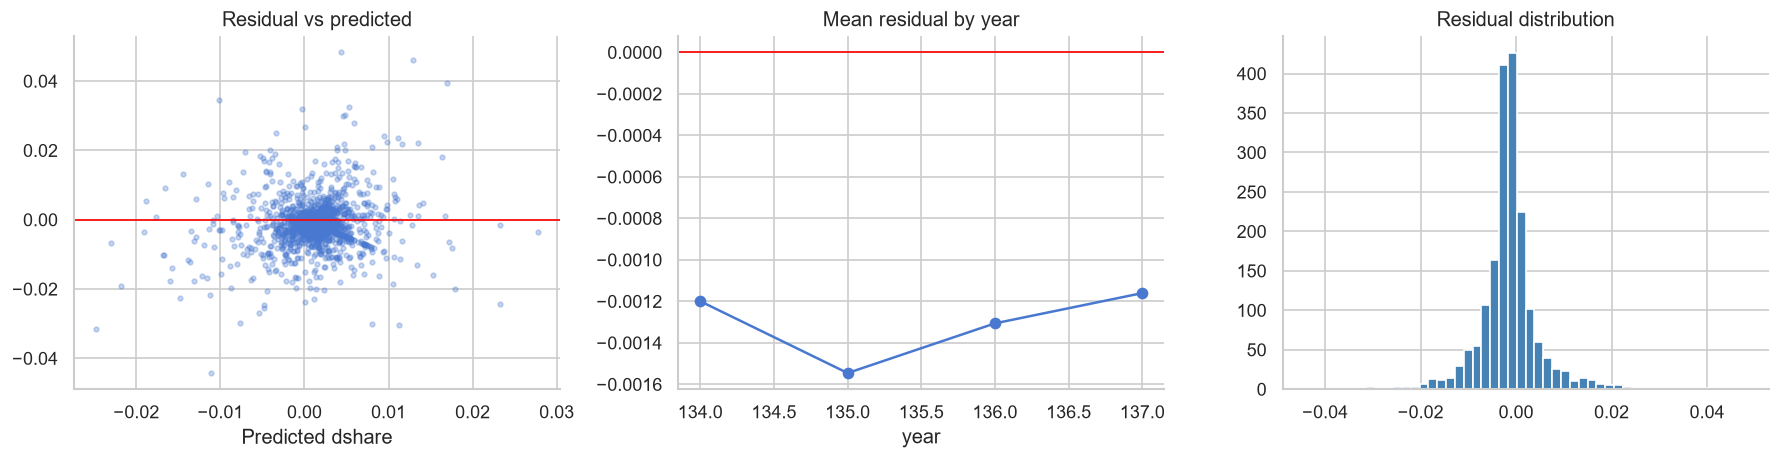

In [47]:
# %% [QA + residual diagnostics]
assert train["year"].max() < SPLIT_YEAR and test["year"].min() >= SPLIT_YEAR
assert SELECT_END < SPLIT_YEAR
assert dm.duplicated(subset=["subject", "word", "year"]).sum() == 0
assert dm["share"].between(0, 1).all() and dm["share_next"].between(0, 1).all()
print("QA pass: split clean, selection precedes test, no dupes, shares in [0,1]")

tc["residual"] = y_te - pred_ridge
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].scatter(pred_ridge, tc["residual"], alpha=0.3, s=8)
axes[0].axhline(0, color="red", lw=1)
axes[0].set_xlabel("Predicted dshare"); axes[0].set_title("Residual vs predicted")
tc.groupby("year")["residual"].mean().plot(ax=axes[1], marker="o")
axes[1].axhline(0, color="red", lw=1); axes[1].set_title("Mean residual by year")
axes[2].hist(tc["residual"], bins=50, color="steelblue")
axes[2].set_title("Residual distribution")
sns.despine(); plt.tight_layout()
plt.savefig("images/model_residual_diagnostics.png", dpi=150, bbox_inches="tight")
plt.show()


                         RMSE      MAE  dir_acc     NDCG
Model                                                   
Dummy (mean)         0.008161 0.004741 0.480171 0.807833
Zero-change          0.008158 0.004718 0.000000 0.807833
Momentum (slope_3yr) 0.010534 0.006330 0.342892 0.719356
Ridge (weighted)     0.006698 0.004298 0.640635 0.900312
HistGBR (weighted)   0.006894 0.004316 0.647956 0.894138


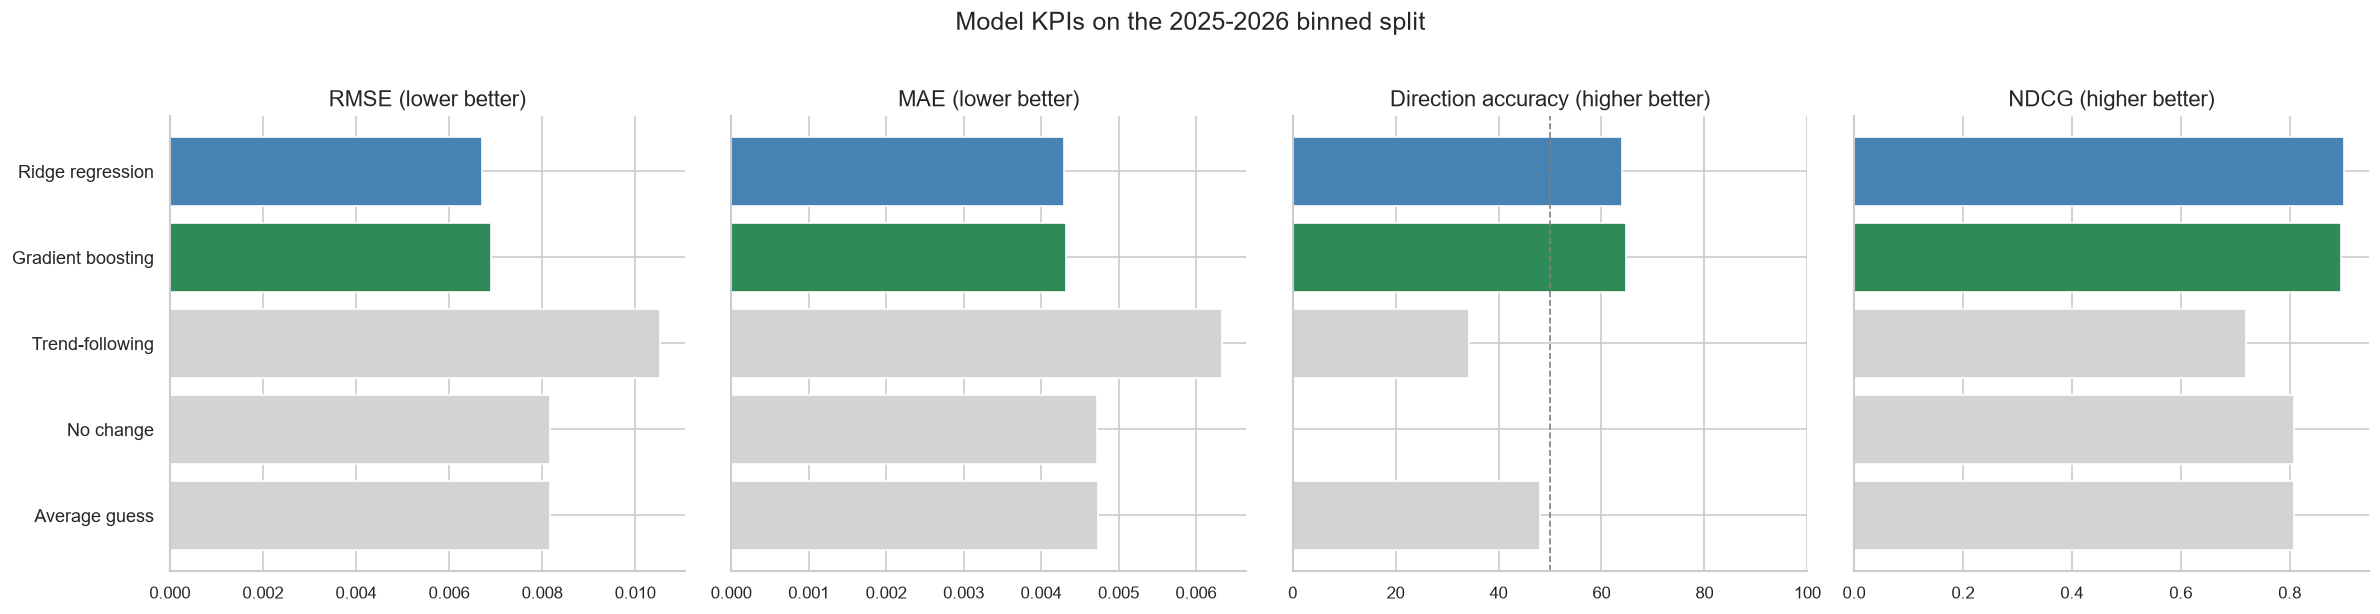

In [48]:
# %% [KPI table + 4-panel comparison figure -- single binned split]
from sklearn.dummy import DummyRegressor

def kpis(y_true, y_pred, groups_df=None):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    nz   = y_true != 0
    dacc = (np.sign(y_pred[nz]) == np.sign(y_true[nz])).mean() if nz.any() else np.nan
    if groups_df is not None:
        gg = groups_df.copy(); gg["pred"] = y_pred
        vals = []
        for _, grp in gg.groupby(["subject", "year"]):
            if len(grp) < 5:
                continue
            rel = grp["dshare"].values - grp["dshare"].values.min()
            vals.append(ndcg_score([rel], [grp["pred"].values]))
        ndcg = float(np.mean(vals)) if vals else np.nan
    else:
        ndcg = np.nan
    return rmse, mae, dacc, ndcg

# --- predictions for all five models on this split ---
dummy = DummyRegressor(strategy="mean").fit(X_tr, y_tr, sample_weight=w_tr)
pred_dummy = dummy.predict(X_te)
pred_zero  = np.zeros(len(y_te))
pred_mom   = test["slope_3yr"].values

scaler = StandardScaler().fit(X_tr)
ridge  = Ridge(alpha=1.0).fit(scaler.transform(X_tr), y_tr, sample_weight=w_tr)
pred_ridge = ridge.predict(scaler.transform(X_te))

gbr = HistGradientBoostingRegressor(max_depth=3, learning_rate=0.05,
                                    max_iter=400, random_state=42)
gbr.fit(X_tr, y_tr, sample_weight=w_tr)
pred_gbr = gbr.predict(X_te)

results = {
    "Dummy (mean)":         pred_dummy,
    "Zero-change":          pred_zero,
    "Momentum (slope_3yr)": pred_mom,
    "Ridge (weighted)":     pred_ridge,
    "HistGBR (weighted)":   pred_gbr,
}

rows = []
for name, pred in results.items():
    r, m, d, n = kpis(y_te, pred, groups_df=test)
    rows.append({"Model": name, "RMSE": r, "MAE": m, "dir_acc": d, "NDCG": n})
kpi = pd.DataFrame(rows).set_index("Model")

pd.set_option("display.float_format", lambda x: f"{x:.6f}")
print(kpi.to_string())
pd.reset_option("display.float_format")
kpi.to_csv(f"data/kpi_summary_{PIPELINE_VERSION}.csv")

# --- 4-panel comparison figure: fixed order, best on top, consistent across panels ---
order = ["Ridge (weighted)", "HistGBR (weighted)",
         "Momentum (slope_3yr)", "Zero-change", "Dummy (mean)"]
kp = kpi.reindex(order)

nice = {
    "Ridge (weighted)":     "Ridge regression",
    "HistGBR (weighted)":   "Gradient boosting",
    "Momentum (slope_3yr)": "Trend-following",
    "Zero-change":          "No change",
    "Dummy (mean)":         "Average guess",
}
labels = [nice[m] for m in kp.index]
color  = {"Ridge (weighted)": "steelblue", "HistGBR (weighted)": "seagreen"}
colors = [color.get(m, "lightgray") for m in kp.index]

metrics = [("RMSE",    "RMSE (lower better)"),
           ("MAE",     "MAE (lower better)"),
           ("dir_acc", "Direction accuracy (higher better)"),
           ("NDCG",    "NDCG (higher better)")]

y = np.arange(len(order))[::-1]   # row 0 at top

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for i, (ax, (col, title)) in enumerate(zip(axes, metrics)):
    vals = kp[col].values * (100 if col == "dir_acc" else 1)
    ax.barh(y, vals, color=colors)
    ax.set_yticks(y)
    ax.set_yticklabels(labels if i == 0 else [], fontsize=11)
    ax.set_title(title, fontsize=13)
    ax.tick_params(axis="x", labelsize=10)
    if col == "dir_acc":
        ax.axvline(50, color="gray", ls="--", lw=1)
        ax.set_xlim(0, 100)
    sns.despine(ax=ax)

fig.suptitle("Model KPIs on the 2025-2026 binned split", fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig(f"images/model_kpi_comparison_{PIPELINE_VERSION}.png",
            dpi=150, bbox_inches="tight")
plt.show()

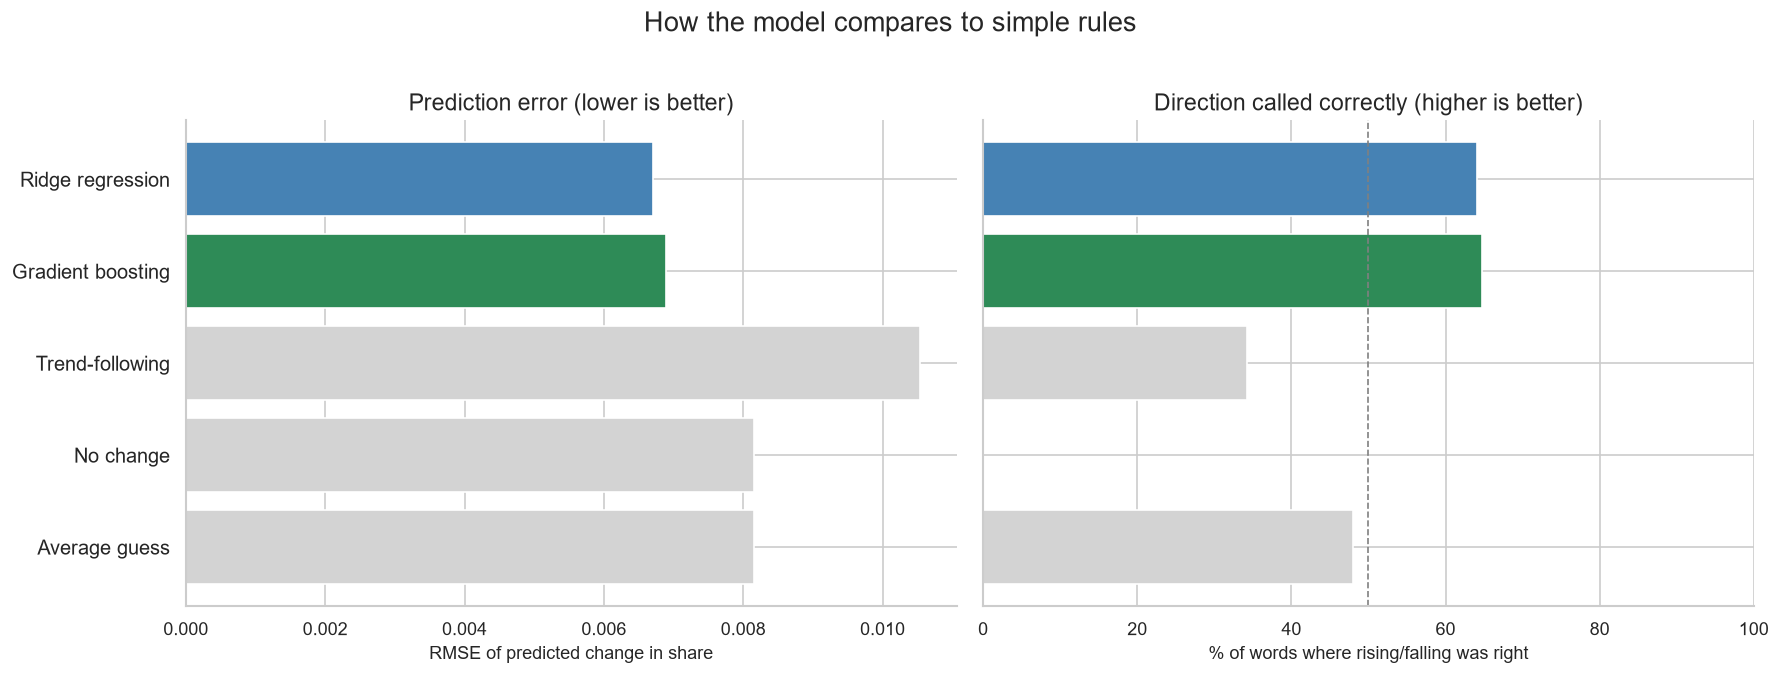

In [49]:
# --- slide figure: 2 KPIs, clean labels, best on top ---
order = ["Ridge (weighted)", "HistGBR (weighted)",
         "Momentum (slope_3yr)", "Zero-change", "Dummy (mean)"]
kp = kpi.reindex(order)

# friendlier labels for the audience
nice = {
    "Ridge (weighted)":     "Ridge regression",
    "HistGBR (weighted)":   "Gradient boosting",
    "Momentum (slope_3yr)": "Trend-following",
    "Zero-change":          "No change",
    "Dummy (mean)":         "Average guess",
}
labels = [nice[m] for m in kp.index]
color  = {"Ridge (weighted)": "steelblue", "HistGBR (weighted)": "seagreen"}
colors = [color.get(m, "lightgray") for m in kp.index]

y = np.arange(len(order))[::-1]   # row 0 at top

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# panel 1: RMSE (lower is better)
axes[0].barh(y, kp["RMSE"].values, color=colors)
axes[0].set_yticks(y); axes[0].set_yticklabels(labels, fontsize=12)
axes[0].set_title("Prediction error (lower is better)", fontsize=14)
axes[0].set_xlabel("RMSE of predicted change in share", fontsize=11)

# panel 2: direction accuracy as percent (higher is better)
axes[1].barh(y, kp["dir_acc"].values * 100, color=colors)
axes[1].set_yticks(y); axes[1].set_yticklabels([])   # share labels with left panel
axes[1].axvline(50, color="gray", ls="--", lw=1)     # coin-flip reference
axes[1].set_title("Direction called correctly (higher is better)", fontsize=14)
axes[1].set_xlabel("% of words where rising/falling was right", fontsize=11)
axes[1].set_xlim(0, 100)

for ax in axes:
    ax.tick_params(axis="x", labelsize=11)
    sns.despine(ax=ax)

fig.suptitle("How the model compares to simple rules", fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig(f"images/model_kpi_slide_{PIPELINE_VERSION}.png",
            dpi=150, bbox_inches="tight")
plt.show()

In [50]:
# %% [watchlist for TREND_END + 1 -- full data allowed here (deployment)]
# This is the only place full data (up to TREND_END) is used for selection,
# by design: we're making live forward predictions here, not evaluating.
# Forecast target is the TREND_END + 1 bin = 2025-2026.
FCAST_BIN   = TREND_END + 1
FCAST_LABEL = period_labels[FCAST_BIN]           # "2025-2026"

rising_now = select_rising_pairs(df, subj_year_tot, end_year=TREND_END)
pairs_now  = rising_now[["subject", "word"]].drop_duplicates()

panel_now = build_feature_panel(df, subj_year_tot, pairs_now)
latest = panel_now[panel_now["year"] == TREND_END].dropna(subset=FEATURES).copy()

# refit on ALL leak-free panel rows for deployment
sc_f = StandardScaler()
r_f  = Ridge(alpha=1.0)
r_f.fit(sc_f.fit_transform(dm[FEATURES]), dm["dshare"], sample_weight=dm["total_next"])

latest["pred_dshare"] = r_f.predict(sc_f.transform(latest[FEATURES]))
latest["pred_share"]  = latest["share"] + latest["pred_dshare"]

watch = latest.merge(meta, on="subject")
# rank by predicted SHARE (top words), not predicted change (top movers)
top5 = (watch.sort_values("pred_share", ascending=False)
        .groupby("subject_name").head(5)
        [["subject_name", "word", "share", "pred_share", "pred_dshare",
          "slope_3yr", "spec_cum"]]
        .sort_values(["subject_name", "pred_share"], ascending=[True, False])
        .reset_index(drop=True))
top5.to_csv(f"data/watchlist_{FCAST_LABEL}_{PIPELINE_VERSION}.csv", index=False)
print(f"Saved watchlist_{FCAST_LABEL}_{PIPELINE_VERSION}.csv | {len(top5)} words, "
      f"{top5['subject_name'].nunique()} subjects (forecast bin {FCAST_BIN} = {FCAST_LABEL})")
top5.head(100)

Saved watchlist_2025-2026_v5_final.csv | 250 words, 50 subjects (forecast bin 139 = 2025-2026)


,subject_name,word,share,pred_share,pred_dshare,slope_3yr,spec_cum
0,Abstract harmonic analysis,group,0.059701,0.045724,-0.013977,0.010983,11.592389
1,Abstract harmonic analysis,space,0.044776,0.039125,-0.005651,0.003520,6.401715
2,Abstract harmonic analysis,compact,0.044776,0.028319,-0.016457,0.008237,46.642317
3,Abstract harmonic analysis,operator,0.044776,0.027963,-0.016814,0.012954,6.847721
4,Abstract harmonic analysis,algebra,0.029851,0.015511,-0.014340,0.014925,8.099062
...,...,...,...,...,...,...,...
95,"Game theory, economics, social and behavioral ...",game,0.017635,0.016226,-0.001409,-0.000590,4.398750
96,"Game theory, economics, social and behavioral ...",health,0.009336,0.010051,0.000715,0.000835,5.181872
97,"Game theory, economics, social and behavioral ...",insurance,0.005187,0.005761,0.000574,0.001548,4.648158
98,"Game theory, economics, social and behavioral ...",equilibrium,0.006224,0.004967,-0.001257,0.002067,4.554591


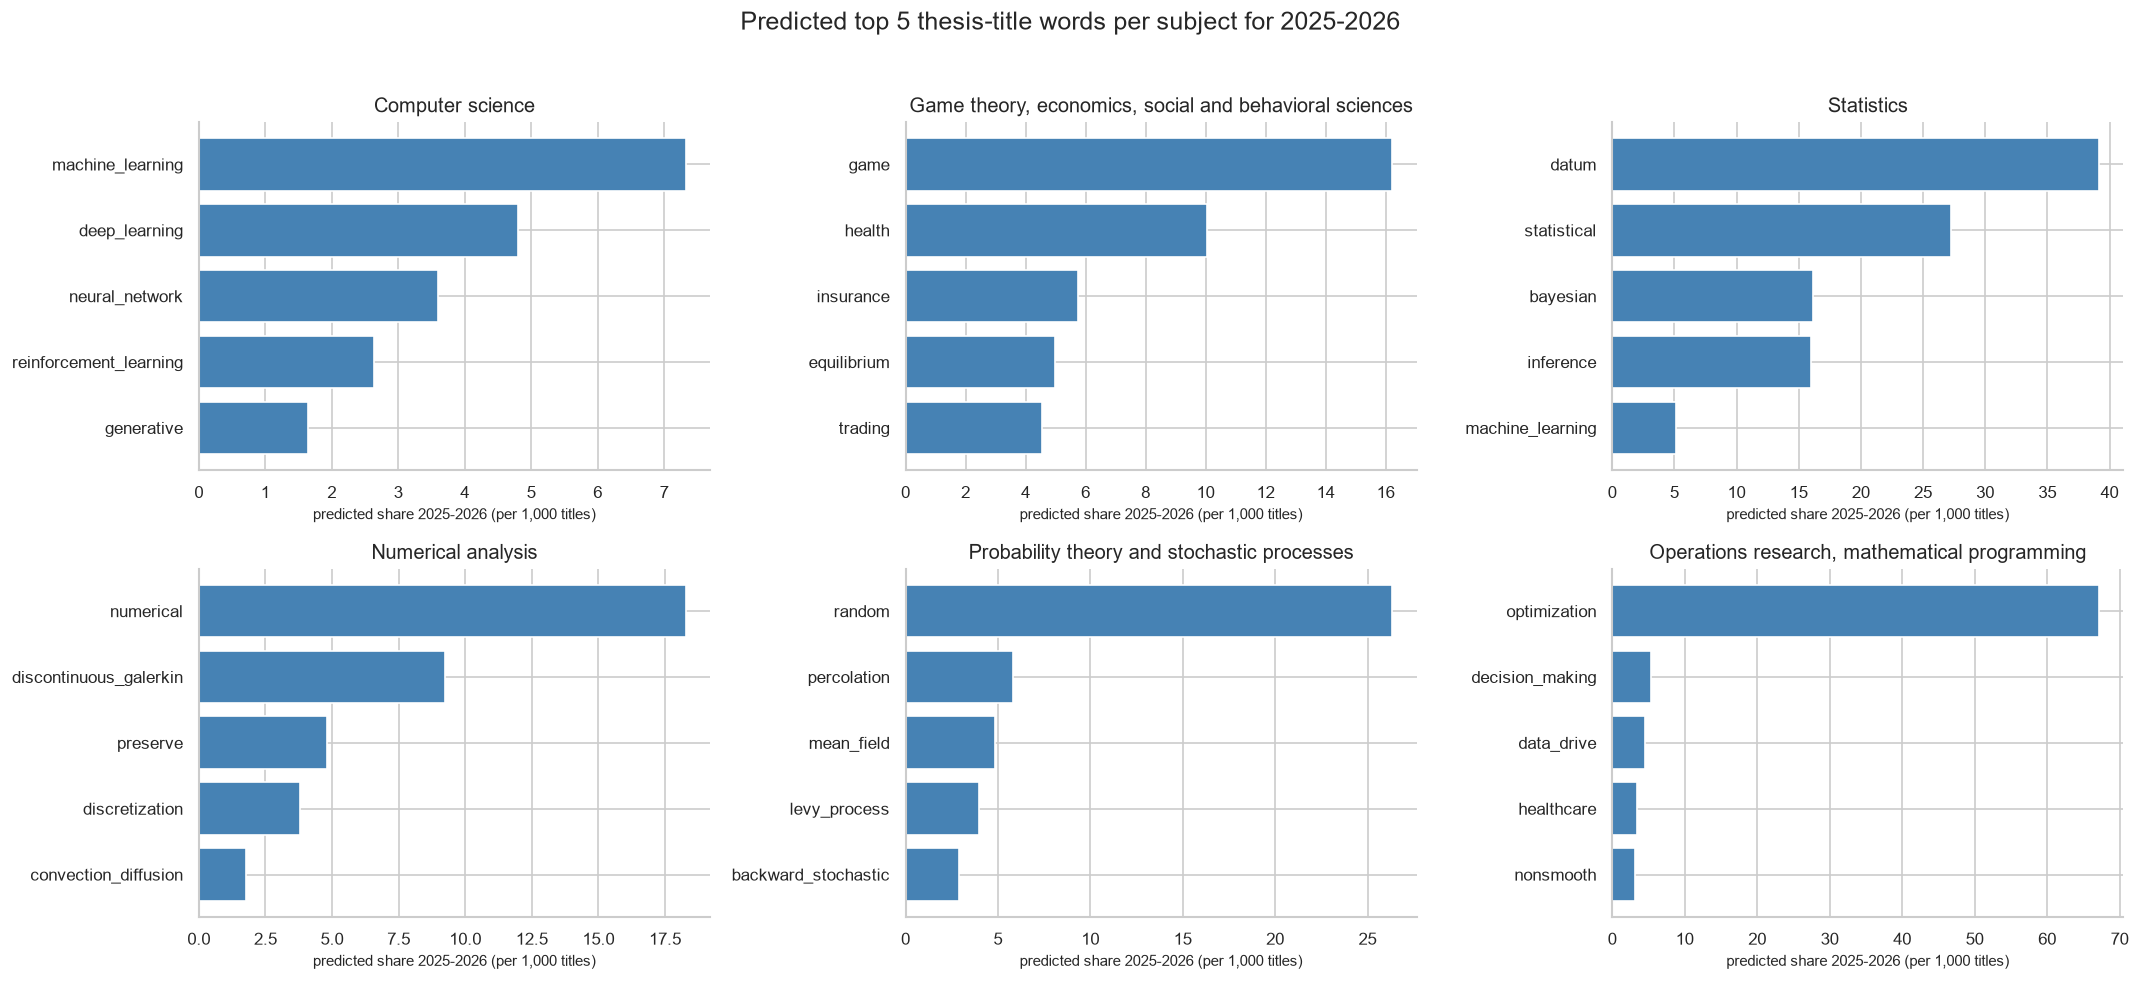

In [51]:
# %% [presentation watchlist: true top 5 predicted words by share, biggest subjects]
PER          = 1000   # appearances per 1,000 title words
N_SUBJECTS   = 6
WORDS        = 5
FCAST_LABEL  = period_labels[TREND_END + 1]      # "2025-2026"

# biggest subjects by title count
subject_rank = (
    meta.sort_values("n_titles", ascending=False)
    .head(N_SUBJECTS)["subject_name"].tolist()
)

# genuine top 5 by predicted share, per subject, from the FULL panel
top_share = (
    watch.sort_values("pred_share", ascending=False)
    .groupby("subject_name").head(WORDS)
)

ncols = 3
nrows = -(-N_SUBJECTS // ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4 * nrows))
axes = axes.flatten()

for ax, subj in zip(axes, subject_rank):
    sub = (top_share[top_share["subject_name"] == subj]
           .nlargest(WORDS, "pred_share")
           .sort_values("pred_share"))
    ax.barh(sub["word"], sub["pred_share"] * PER, color="steelblue")
    ax.set_title(subj, fontsize=12)
    ax.set_xlabel(f"predicted share {FCAST_LABEL} (per {PER:,} titles)", fontsize=9)
    ax.tick_params(labelsize=10)
    sns.despine(ax=ax)

for ax in axes[len(subject_rank):]:
    ax.set_visible(False)

fig.suptitle(f"Predicted top 5 thesis-title words per subject for {FCAST_LABEL}",
             fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig(f"images/watchlist_top5share_{FCAST_LABEL}_{PIPELINE_VERSION}.png",
            dpi=150, bbox_inches="tight")
plt.show()

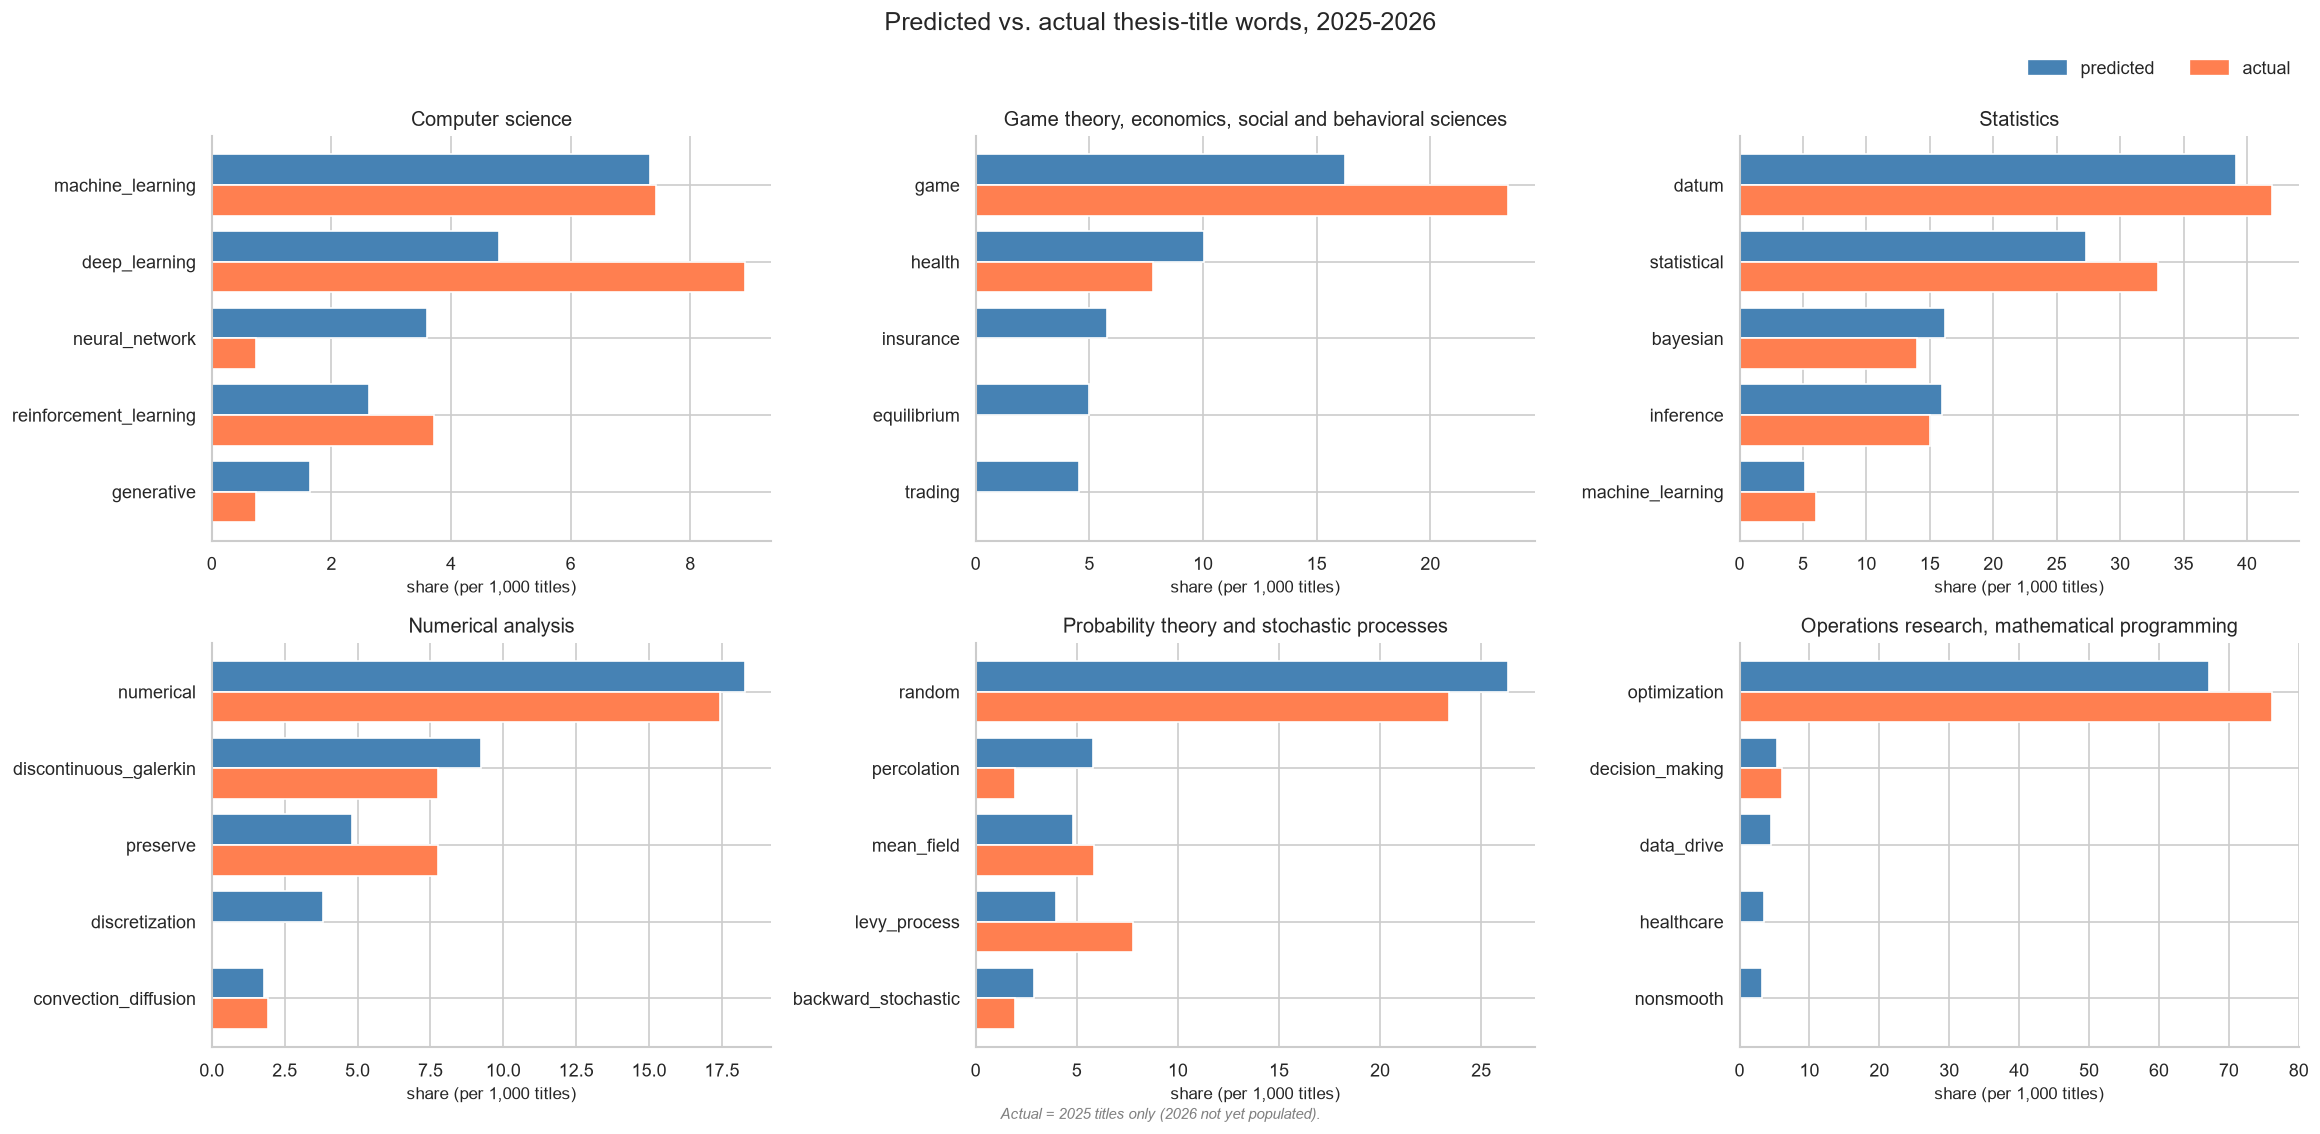

In [52]:
# %% [README figure: predicted vs actual, 6 subjects, 2025 data]
PER = 1000
N_SUBJECTS = 6

# 2025-only actuals (2026 not populated)
raw_actual = pd.read_parquet(f"data/word_year_subject_{PIPELINE_VERSION}.parquet")
sub25 = raw_actual[raw_actual["year"] == 2025].copy()

tot25 = (sub25.groupby(["subject", "year"])["total_title_words"].first()
         .groupby("subject").sum().rename("total_actual"))
cnt25 = (sub25.groupby(["subject", "word"])["count"].sum()
         .rename("count_actual").reset_index())

cand = watch[["subject", "word"]].drop_duplicates()
act25 = (cand.merge(cnt25, on=["subject", "word"], how="left").fillna({"count_actual": 0})
             .merge(tot25, on="subject", how="left")
             .merge(meta[["subject", "subject_name"]], on="subject"))
act25["share_actual"] = act25["count_actual"] / act25["total_actual"]

merged = (watch[["subject", "subject_name", "word", "pred_share"]]
          .merge(act25[["subject", "word", "share_actual"]],
                 on=["subject", "word"], how="left")
          .fillna({"share_actual": 0}))

subject_rank = (meta.sort_values("n_titles", ascending=False)
                .head(N_SUBJECTS)["subject_name"].tolist())

ncols, nrows = 3, 2
fig, axes = plt.subplots(nrows, ncols, figsize=(6.5 * ncols, 4.5 * nrows))
axes = axes.flatten()

for ax, subj in zip(axes, subject_rank):
    s = (merged[merged["subject_name"] == subj]
         .nlargest(5, "pred_share").sort_values("pred_share"))
    y = np.arange(len(s)); h = 0.4
    ax.barh(y + h/2, s["pred_share"]   * PER, height=h, color="steelblue")
    ax.barh(y - h/2, s["share_actual"] * PER, height=h, color="coral")
    ax.set_yticks(y); ax.set_yticklabels(s["word"], fontsize=11)
    ax.set_title(subj, fontsize=12)
    ax.set_xlabel(f"share (per {PER:,} titles)", fontsize=10)
    sns.despine(ax=ax)

for ax in axes[len(subject_rank):]:
    ax.set_visible(False)

handles = [plt.Rectangle((0,0),1,1,color="steelblue"),
           plt.Rectangle((0,0),1,1,color="coral")]
fig.legend(handles, ["predicted", "actual"], loc="upper right",
           bbox_to_anchor=(0.99, 1.0), ncol=2, frameon=False, fontsize=11)
fig.suptitle("Predicted vs. actual thesis-title words, 2025-2026",
             fontsize=15, y=1.03)
fig.text(0.5, 0.005, "Actual = 2025 titles only (2026 not yet populated).",
         ha="center", fontsize=9, style="italic", color="gray")
plt.tight_layout()
plt.savefig(f"images/pred_vs_actual_6panel_{PIPELINE_VERSION}.png",
            dpi=150, bbox_inches="tight")
plt.show()

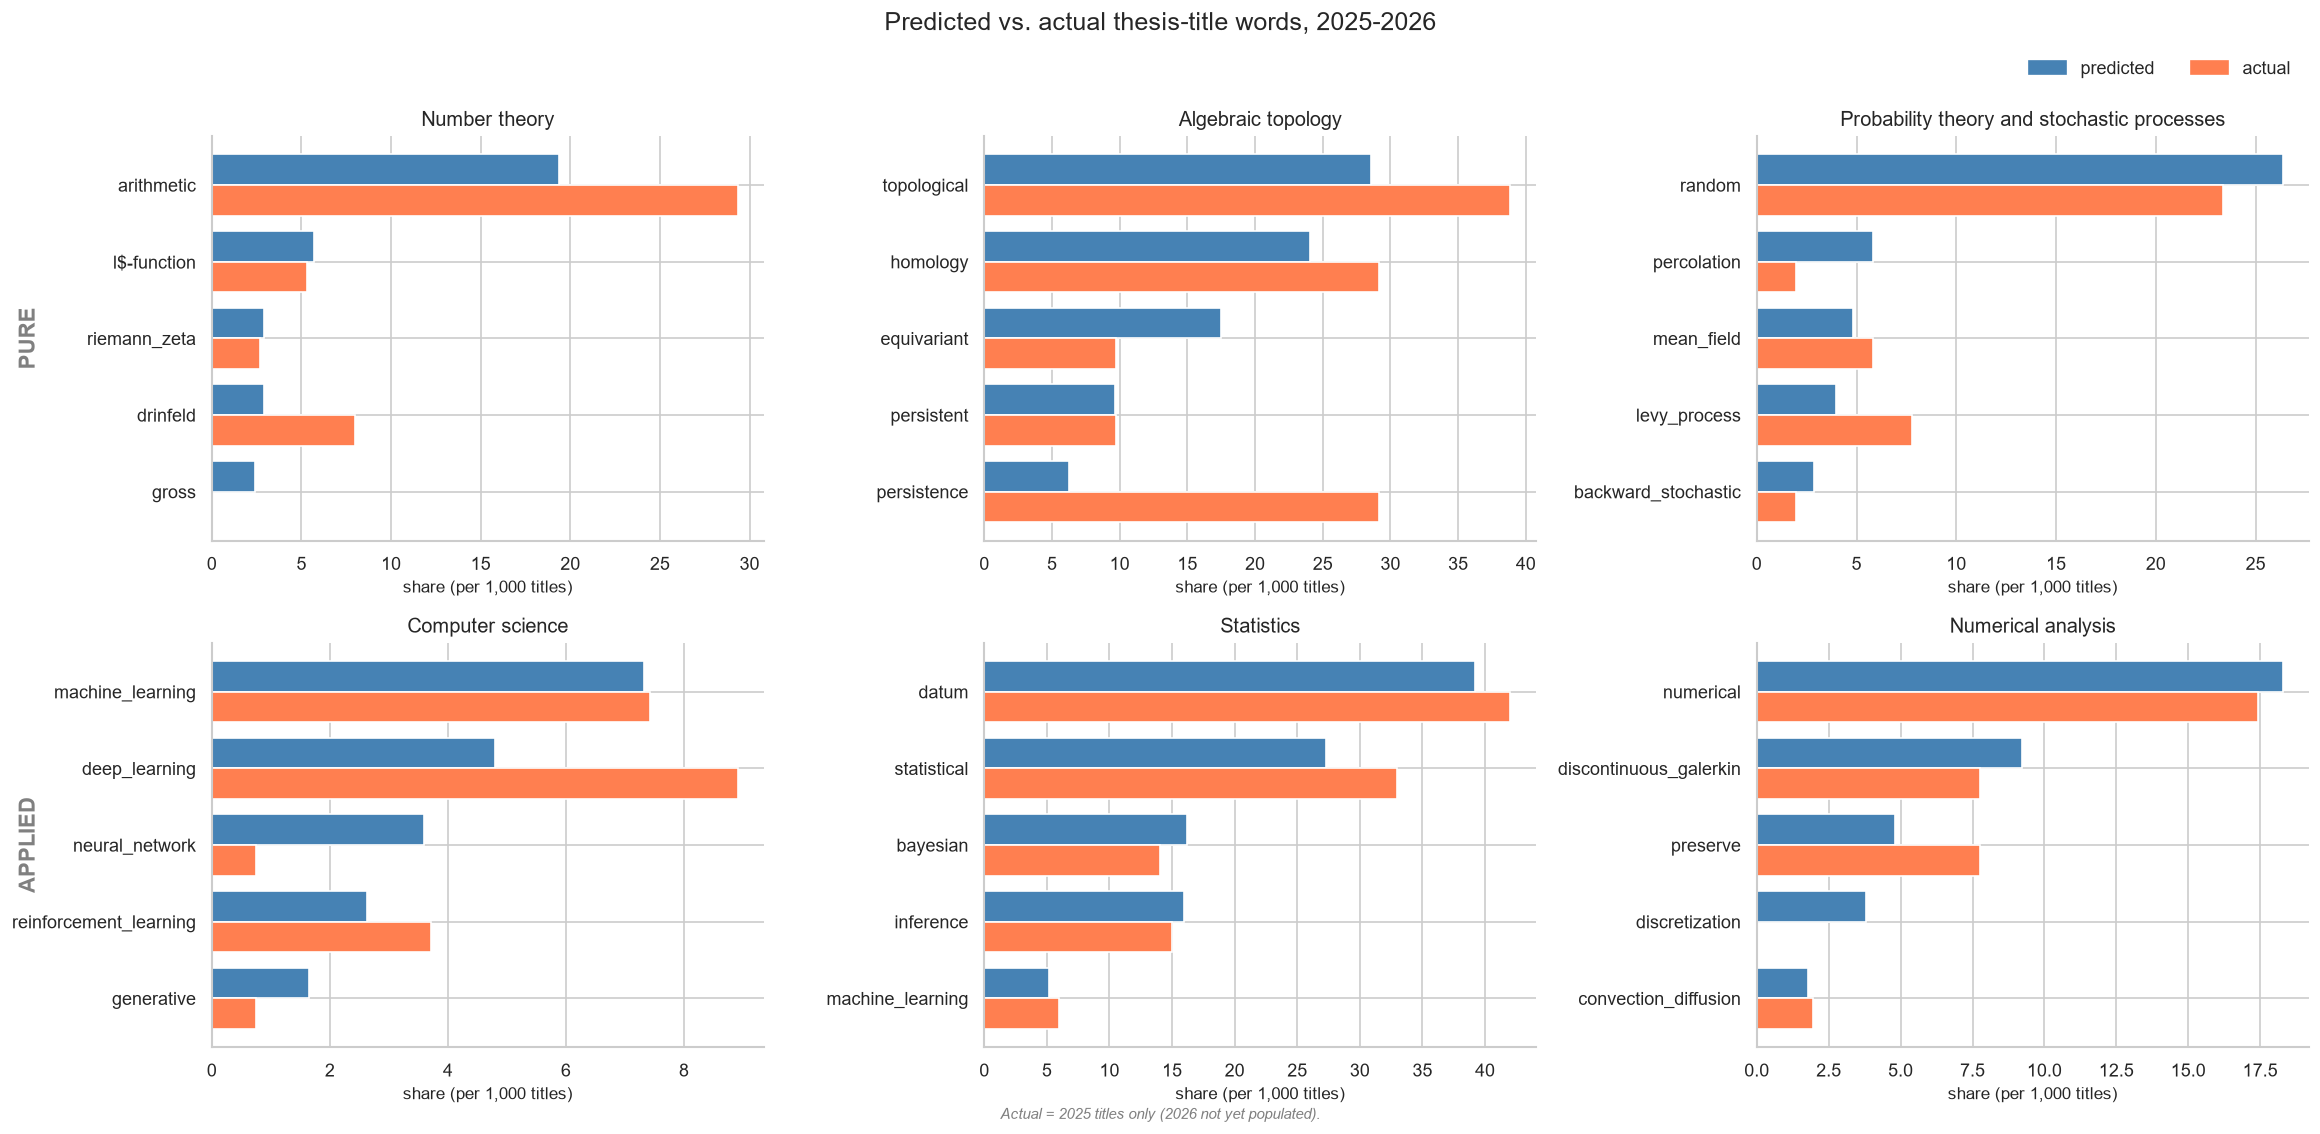

In [53]:
# %% [README figure: predicted vs actual, 3 pure + 3 applied, 2025 data]
PER = 1000

# 3 pure + 3 applied, chosen for good match + enough 2025 data
PURE    = ["Number theory", "Algebraic topology", "Probability theory and stochastic processes"]
APPLIED = ["Computer science", "Statistics", "Numerical analysis"]
SHOW = PURE + APPLIED   # top row pure, bottom row applied

# 2025-only actuals (2026 not populated)
raw_actual = pd.read_parquet(f"data/word_year_subject_{PIPELINE_VERSION}.parquet")
sub25 = raw_actual[raw_actual["year"] == 2025].copy()

tot25 = (sub25.groupby(["subject", "year"])["total_title_words"].first()
         .groupby("subject").sum().rename("total_actual"))
cnt25 = (sub25.groupby(["subject", "word"])["count"].sum()
         .rename("count_actual").reset_index())

cand = watch[["subject", "word"]].drop_duplicates()
act25 = (cand.merge(cnt25, on=["subject", "word"], how="left").fillna({"count_actual": 0})
             .merge(tot25, on="subject", how="left")
             .merge(meta[["subject", "subject_name"]], on="subject"))
act25["share_actual"] = act25["count_actual"] / act25["total_actual"]

merged = (watch[["subject", "subject_name", "word", "pred_share"]]
          .merge(act25[["subject", "word", "share_actual"]],
                 on=["subject", "word"], how="left")
          .fillna({"share_actual": 0}))

ncols, nrows = 3, 2
fig, axes = plt.subplots(nrows, ncols, figsize=(6.5 * ncols, 4.5 * nrows))
axes = axes.flatten()

for ax, subj in zip(axes, SHOW):
    s = (merged[merged["subject_name"] == subj]
         .nlargest(5, "pred_share").sort_values("pred_share"))
    if s.empty:
        ax.set_title(f"{subj}\n(no data)", fontsize=11); ax.set_visible(True); continue
    y = np.arange(len(s)); h = 0.4
    ax.barh(y + h/2, s["pred_share"]   * PER, height=h, color="steelblue")
    ax.barh(y - h/2, s["share_actual"] * PER, height=h, color="coral")
    ax.set_yticks(y); ax.set_yticklabels(s["word"], fontsize=11)
    ax.set_title(subj, fontsize=12)
    ax.set_xlabel(f"share (per {PER:,} titles)", fontsize=10)
    sns.despine(ax=ax)

# row labels
axes[0].text(-0.35, 0.5, "PURE", transform=axes[0].transAxes,
             fontsize=13, fontweight="bold", rotation=90, va="center", color="gray")
axes[3].text(-0.35, 0.5, "APPLIED", transform=axes[3].transAxes,
             fontsize=13, fontweight="bold", rotation=90, va="center", color="gray")

handles = [plt.Rectangle((0,0),1,1,color="steelblue"),
           plt.Rectangle((0,0),1,1,color="coral")]
fig.legend(handles, ["predicted", "actual"], loc="upper right",
           bbox_to_anchor=(0.99, 1.0), ncol=2, frameon=False, fontsize=11)
fig.suptitle("Predicted vs. actual thesis-title words, 2025-2026",
             fontsize=15, y=1.03)
fig.text(0.5, 0.005, "Actual = 2025 titles only (2026 not yet populated).",
         ha="center", fontsize=9, style="italic", color="gray")
plt.tight_layout()
plt.savefig(f"images/pred_vs_actual_pure_applied_{PIPELINE_VERSION}.png",
            dpi=150, bbox_inches="tight")
plt.show()

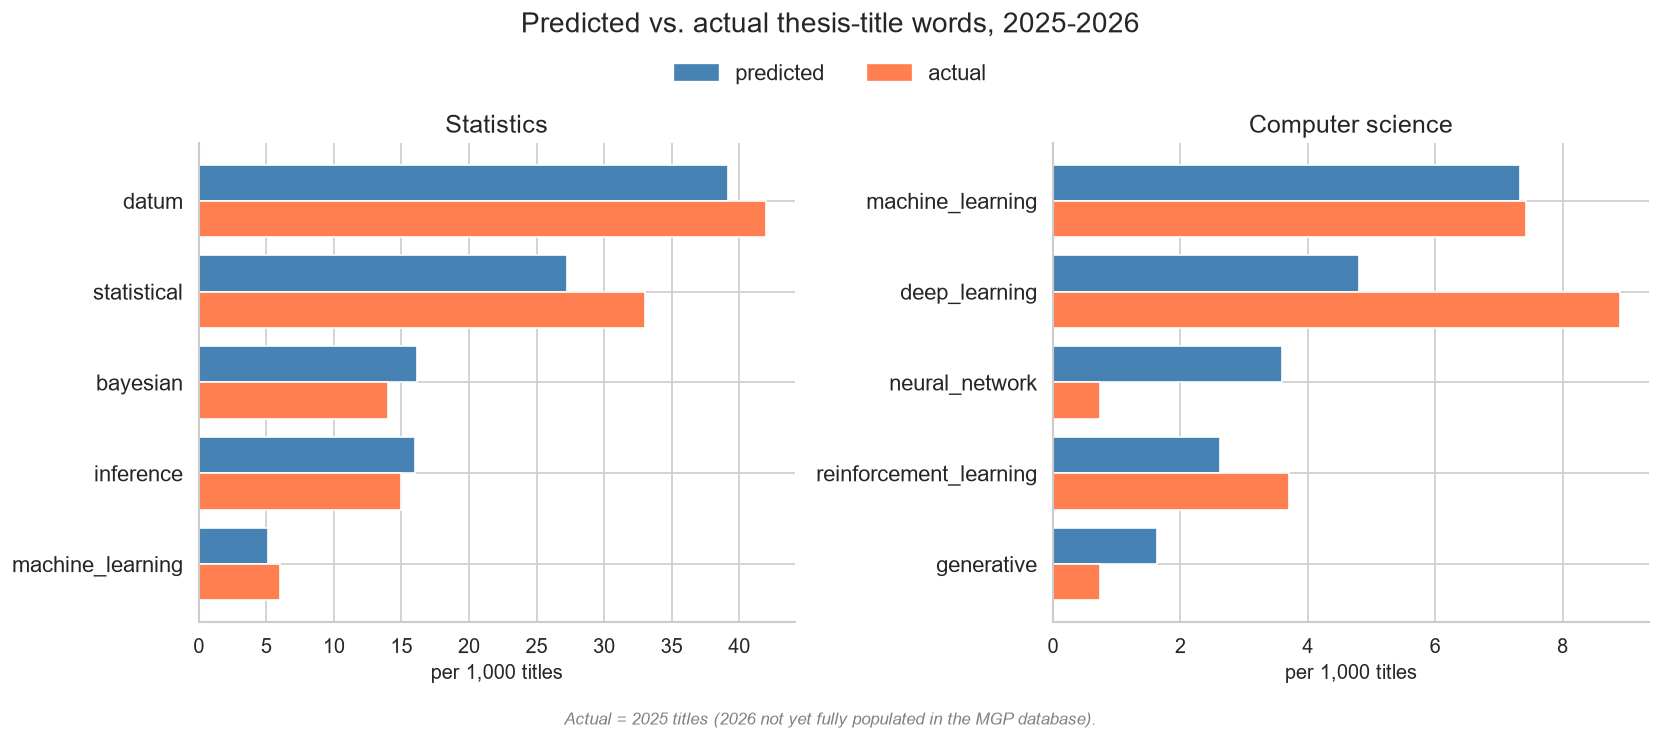

In [54]:
# %% [paired predicted vs actual -- 2 subjects, slide-ready, self-contained]
PER = 1000
SHOW = ["Statistics", "Computer science"]

# build 2025 actuals here so the cell doesn't depend on earlier state
raw_actual = pd.read_parquet(f"data/word_year_subject_{PIPELINE_VERSION}.parquet")
sub25 = raw_actual[raw_actual["year"] == 2025].copy()
tot25 = (sub25.groupby(["subject", "year"])["total_title_words"].first()
         .groupby("subject").sum().rename("total_actual"))
cnt25 = (sub25.groupby(["subject", "word"])["count"].sum()
         .rename("count_actual").reset_index())
act = (watch[["subject", "word"]].drop_duplicates()
       .merge(cnt25, on=["subject", "word"], how="left").fillna({"count_actual": 0})
       .merge(tot25, on="subject", how="left"))
act["share_actual"] = act["count_actual"] / act["total_actual"]

merged = (watch[["subject", "subject_name", "word", "pred_share"]]
          .merge(act[["subject", "word", "share_actual"]],
                 on=["subject", "word"], how="left")
          .fillna({"share_actual": 0}))

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
for ax, subj in zip(axes, SHOW):
    s = (merged[merged["subject_name"] == subj]
         .nlargest(5, "pred_share").sort_values("pred_share"))
    y = np.arange(len(s)); h = 0.4
    ax.barh(y + h/2, s["pred_share"]   * PER, height=h, color="steelblue")
    ax.barh(y - h/2, s["share_actual"] * PER, height=h, color="coral")
    ax.set_yticks(y); ax.set_yticklabels(s["word"], fontsize=13)
    ax.set_title(subj, fontsize=15)
    ax.set_xlabel(f"per {PER:,} titles", fontsize=12)
    ax.tick_params(axis="x", labelsize=12)
    sns.despine(ax=ax)

handles = [plt.Rectangle((0,0),1,1,color="steelblue"),
           plt.Rectangle((0,0),1,1,color="coral")]
fig.legend(handles, ["predicted", "actual"], loc="upper center",
           bbox_to_anchor=(0.5, 1.0), ncol=2, frameon=False, fontsize=13)
fig.suptitle("Predicted vs. actual thesis-title words, 2025-2026",
             fontsize=17, y=1.05)
fig.text(0.5, -0.03, "Actual = 2025 titles (2026 not yet fully populated in the MGP database).",
         ha="center", fontsize=10, style="italic", color="gray")
plt.tight_layout()
plt.savefig(f"images/pred_vs_actual_2panel_{PIPELINE_VERSION}.png",
            dpi=150, bbox_inches="tight")
plt.show()